# Customer Churn Prediction

### Importing libraries

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Data and Splitting

In [2]:
train = pd.read_csv('../Data/ev-purchase/train.csv')
test = pd.read_csv('../Data/ev-purchase/test.csv')

y_train = train['Will_Buy_EV']
train = train.drop(columns= ['Will_Buy_EV', 'id'])

id_test = test['id']
test = test.drop(columns= ['id'])

### Preprocessing

In [3]:
train.head(5)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low


In [4]:
print(train.dtypes)

Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                             str
City_Type                          str
Current_Car_Type                   str
Home_Charging_Possible             str
Subsidy_Available                  str
Range_Anxiety_Level                str
dtype: object


#### Checking null and duplicate values

In [5]:
print(f"train null values:{train.isna().sum().sum()}")
print(f"test null values:{test.isna().sum().sum()}")
print(f"number of duplicate column in training set: {train.duplicated().sum()}")
print(f"number of duplicate column in test set: {test.duplicated().sum()}")

train null values:0
test null values:0
number of duplicate column in training set: 0
number of duplicate column in test set: 0


#### Ordinal Encoding

In [6]:
col_categories = {
    'Home_Charging_Possible' : ['No', 'Yes'],
    'Subsidy_Available' : ['No', 'Yes'],
    'Range_Anxiety_Level' : ['Low', 'Medium', 'High']
}

encoder = {}

for col, categories in col_categories.items():
    enc = OrdinalEncoder(categories = [categories])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])
    encoder[col] = enc

#### One Hot Encoding 

In [7]:
def get_str_col(df):
    return df.select_dtypes(include = 'str').columns.tolist()

train_str_col = get_str_col(train)
test_str_col = get_str_col(test)

ohe = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
train_encoded = ohe.fit_transform(train[train_str_col])
test_encoded = ohe.transform(test[train_str_col])

train_encoded_df = pd.DataFrame(train_encoded, columns = ohe.get_feature_names_out(train_str_col), index = train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns = ohe.get_feature_names_out(test_str_col), index = test.index)

train = train.drop(columns = train_str_col).join(train_encoded_df)
test = test.drop(columns = test_str_col).join(test_encoded_df)

#### Label Encoding

In [8]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)

#### Checking for outliers

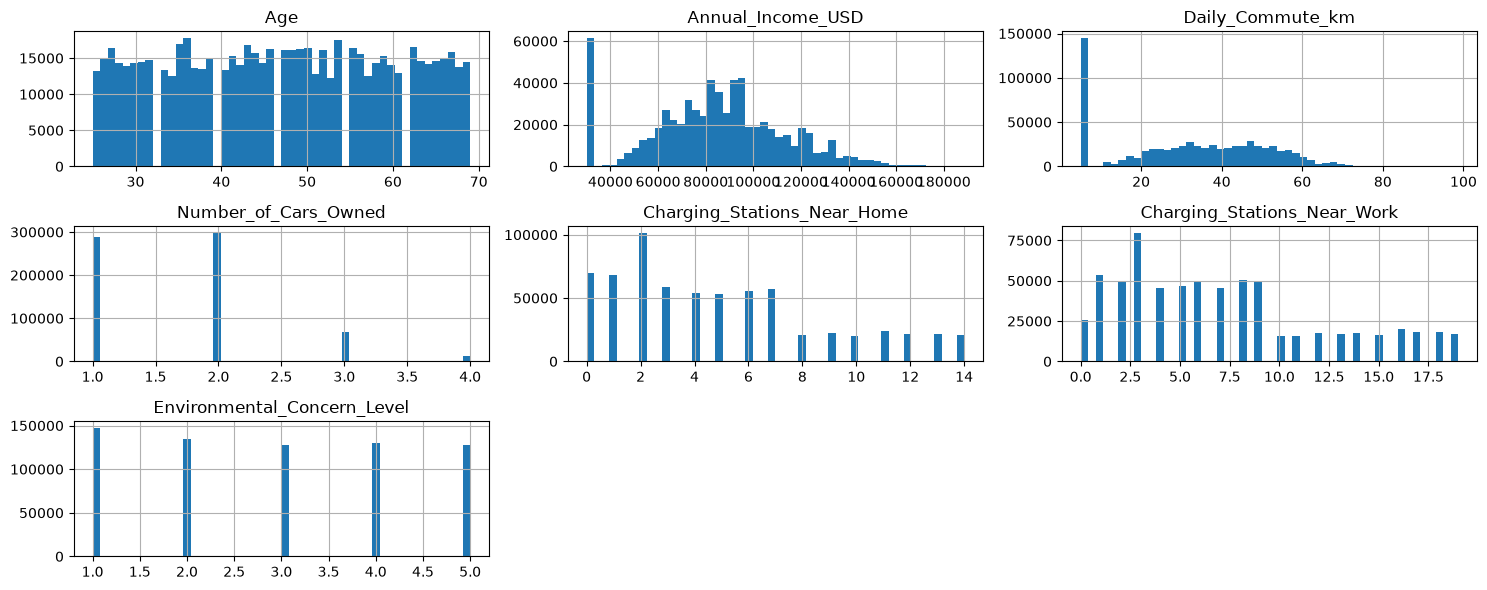

In [24]:
num_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 
            'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
            'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

# for col in num_cols:
#     plt.figure(figsize = (6,2))
#     sns.histplot(x = train[col])
#     plt.title(f'{col} - outlier check')
#     plt.show

train[num_cols].hist(figsize=(15,6), bins=50)
plt.tight_layout()
plt.show()


In [26]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    print(f"{col} : {len(outliers)} outliers ({len(outliers) / len(train) * 100 : .2f}%)")

Age : 0 outliers ( 0.00%)
Annual_Income_USD : 3678 outliers ( 0.55%)
Daily_Commute_km : 41 outliers ( 0.01%)
Number_of_Cars_Owned : 13489 outliers ( 2.02%)
Charging_Stations_Near_Home : 0 outliers ( 0.00%)
Charging_Stations_Near_Work : 0 outliers ( 0.00%)
Environmental_Concern_Level : 0 outliers ( 0.00%)
